# Using PyVRP's components

We have relied on the `Model` interface to solve VRP instances in the examples so far.
That high-level interface hides a lot of the components that available in PyVRP, which uses [an iterated local search algorithm](https://pyvrp.org/setup/introduction_to_ils.html) under the hood.
In this notebook we will investigate these components in more detail to build our own `solve` function based on iterated local search.

Along the way we will solve the `RC208.vrp` instance, one of the well-known VRPTW benchmark instances of Solomon.
This instance consists of 100 clients.

In [1]:
from pyvrp import read

INSTANCE = read("data/RC208.vrp", round_func="dimacs")

We will implement a `solve()` function that will take a `stop` stopping criterion, and a `seed` for the random number generator.
This definition is very close to that of `Model.solve`.
The signature is
```python
def solve(stop: StoppingCriterion, seed: int) -> Solution: ...
```

## A tour of PyVRP

We need to understand the separate components in PyVRP before we are ready to implement this function.
PyVRP uses an iterated local search algorithm under the hood.
The `IteratedLocalSearch` object manages a current solution.
In each iteration, the current solution is modified using a method from `pyvrp.search` -- this method should perform both perturbation and improvement steps.
This candidate solution is then considered for acceptance based on a dynamic threshold value.
This process continues until a stopping condition is reached (see `pyvrp.stop` for different conditions).
Let's have a look at the different parts of `pyvrp` that are used to implement this algorithm.

To instantiate the `IteratedLocalSearch`, we need to specify an initial solution, search method, penalty manager and random number generator.
Let's start with the random number generator because it is the easiest to set up.

##### Random number generator

In [2]:
from pyvrp import RandomNumberGenerator

rng = RandomNumberGenerator(seed=42)

##### Search method

Let's now define the search method.
The search method applies both perturbation and improvement steps.
PyVRP implements a `LocalSearch` method that is very customisable with different operators and search neighbourhoods.
Different operators search different parts of the solution space, which can be beneficial in finding better solutions.
The search neighbourhood defines which edges are evaluated.
By restricting that set of edges the local search method works much faster.

We provide default operator sets and neighbourhoods, which can be used as follows.

In [3]:
from pyvrp.search import NODE_OPERATORS, LocalSearch, compute_neighbours

neighbours = compute_neighbours(INSTANCE)
ls = LocalSearch(INSTANCE, rng, neighbours)

for node_op in NODE_OPERATORS:
    ls.add_node_operator(node_op(INSTANCE))

##### Solution representation and evaluation

We now have a functioning local search method.
All we need are two additional components to make it work: an initial `Solution` containing a set of routes, and a `CostEvaluator` that can be used to evaluate different moves.
Let's define those.

In [4]:
from pyvrp import CostEvaluator, Solution

sol = Solution.make_random(INSTANCE, rng)
cost_evaluator = CostEvaluator(
    load_penalties=[20],
    tw_penalty=20,
    dist_penalty=0,
)

The random solution `sol` that we created just yet is not feasible.
This is not a problem, because PyVRP internally uses penalties to evaluate infeasibilities in each solution.
This is done using the `CostEvaluator`'s `penalised_cost` function, which allows us to determine the quality of infeasible solutions as well.

In [5]:
assert not sol.is_feasible()
print(cost_evaluator.penalised_cost(sol))

142556


Let's see if the local search can improve this solution.

In [6]:
new_sol = ls.search(sol, cost_evaluator)

assert not sol.is_feasible()
print(cost_evaluator.penalised_cost(new_sol))

8280


Much better! 
But the new solution is not yet feasible.
Can we hammer out the infeasibilities by increasing the penalties?

In [7]:
cost_evaluator = CostEvaluator([200], 200, 0)
new_sol = ls.search(sol, cost_evaluator)

assert new_sol.is_feasible()

How good is this solution?

In [8]:
print(cost_evaluator.penalised_cost(new_sol))

8304


Pretty good!
This is how PyVRP manages infeasibilities: it adjusts the penalty parameters to ensure sufficiently many solutions are feasible.
Too few feasible solutions and the penalties go up; too many and they go down.
This ensures a balanced search of feasible and infeasible solutions, which is good for exploration.

The object in charge of managing the penalty terms is the `PenaltyManager`, which can be asked to provide a `CostEvaluator` of the form we saw above.

In [9]:
from pyvrp import PenaltyManager

pen_manager = PenaltyManager.init_from(INSTANCE)
cost_evaluator = pen_manager.cost_evaluator()

An initial solution can be constructed easily using the random solution constructor:

In [10]:
init_sol = Solution.make_random(INSTANCE, rng)

We are now ready to construct the iterated local search algorithm.

In [11]:
from pyvrp import IteratedLocalSearch

algo = IteratedLocalSearch(INSTANCE, pen_manager, rng, ls, init_sol)

We can call `algo.run`, which iterates until a stopping criterion is met.
These stopping criteria can be imported from `pyvrp.stop` - see [the API documentation](https://pyvrp.org/api/stop.html) for details.

In [12]:
from pyvrp.stop import MaxIterations, MaxRuntime

iter_res = algo.run(stop=MaxIterations(2000))
time_res = algo.run(stop=MaxRuntime(1))  # seconds

Let's investigate the solutions!

In [13]:
print(iter_res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
   objective: 7833
    distance: 7833
    duration: 17833
# iterations: 2000
    run-time: 1.20 seconds

Routes
------
Route #1: 90 65 82 99 52 83 64 49 19 18 48 21 23 25 77 58 75 97 59 87 74 86 57 24 22 20 66
Route #2: 61 81 94 93 71 72 42 44 43 40 36 35 37 38 39 41 54 96
Route #3: 92 95 67 62 50 34 31 29 27 26 28 30 32 33 76 89 63 85 51 84 56 91 80
Route #4: 69 98 88 2 6 79 73 78 12 14 47 16 17 15 13 9 11 10 53 60 7 8 46 4 45 5 3 1 70 100 55 68



In [14]:
print(time_res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
   objective: 7839
    distance: 7839
    duration: 17839
# iterations: 1687
    run-time: 1.00 seconds

Routes
------
Route #1: 92 95 67 62 50 34 31 29 27 26 28 30 32 33 76 89 63 85 51 84 56 91 80
Route #2: 90 65 82 99 52 83 64 49 19 18 48 21 23 25 77 58 75 97 59 87 74 86 57 24 22 20 66
Route #3: 69 98 88 53 78 12 14 47 16 15 13 9 10 11 17 73 79 7 2 8 46 45 5 3 1 4 6 60 55 100 70 68
Route #4: 61 81 94 93 71 72 42 44 43 40 36 35 37 38 39 41 54 96



## The `solve` function

Let's put everything we have learned together into a `solve` function.

In [15]:
def solve(stop, seed):
    rng = RandomNumberGenerator(seed=seed)
    pm = PenaltyManager.init_from(INSTANCE)

    neighbours = compute_neighbours(INSTANCE)
    ls = LocalSearch(INSTANCE, rng, neighbours)

    for node_op in NODE_OPERATORS:
        ls.add_node_operator(node_op(INSTANCE))

    init = Solution.make_random(INSTANCE, rng)
    algo = IteratedLocalSearch(INSTANCE, pm, rng, ls, init)

    return algo.run(stop)

Very good.
Let's solve the instance again, now using the `solve` function.

In [16]:
res = solve(stop=MaxIterations(2000), seed=1)
print(res)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
   objective: 7768
    distance: 7768
    duration: 17768
# iterations: 2000
    run-time: 1.21 seconds

Routes
------
Route #1: 69 98 88 2 6 7 79 73 78 12 14 47 17 16 15 13 9 11 10 53 60 8 46 4 45 5 3 1 70 100 55 68
Route #2: 90 65 82 99 52 83 64 49 19 18 48 21 23 25 77 58 75 97 59 87 74 86 57 24 22 20 66
Route #3: 81 61 42 44 39 38 36 35 37 40 43 41 72 71 93 94 96 54
Route #4: 92 95 67 62 50 34 31 29 27 26 28 30 32 33 76 89 63 85 51 84 56 91 80



PyVRP also provides many plotting tools that can be used to investigate a data instance or solution result.

In [17]:
import matplotlib.pyplot as plt

from pyvrp.plotting import plot_result

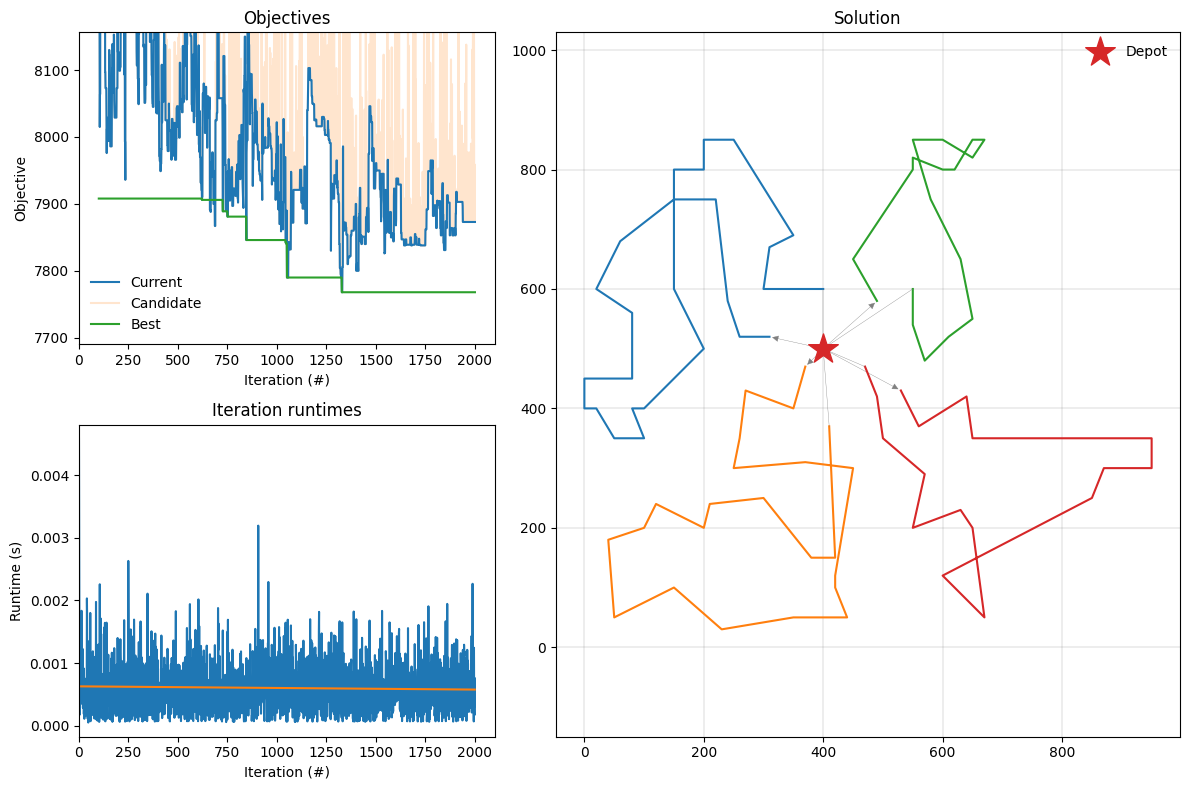

In [18]:
fig = plt.figure(figsize=(12, 8))

plot_result(res, INSTANCE, fig=fig)
plt.tight_layout()

The top-left figure shows the penalised costs of the current, candidate, and best solutions across iterations.
The fluctuations in current solution cost demonstrates the acceptance criterion's strategy: while generally favoring improvements, it occasionally accepts worse solutions to escape local minima.
Meanwhile, the candidate solution cost variations show the perturbation strategy - generating diverse solutions that, although occasionally being significantly worse, are essential to finding superior solutions throughout the search.
The bottom-left figure shows average iteration runtimes (in seconds).
Finally, the figure on the right plots the best observed solution.

## Conclusion

In this notebook we have used some of the different components in PyVRP to implement our own `solve` function.
Along the way we learned about how PyVRP works internally.